# Random Forest Classifier Model
- This model focus on country specific only.
- To use this notebook, you would need to run it several times and change the target and country variable.

### Import all the library and frameworks

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
import shap, joblib, os

### Data path to different folders

In [86]:
data_path = "../data/datasets/panel_dataset_VIF_normalized.xlsx"
importance_dir = "../data/feature_importance/per_country"
model_dir = "../models/per_country"
metrics_dir = "../data/evaluation_metrics/per_country"
shap_dir = "../data/shap_values"

os.makedirs(importance_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(metrics_dir, exist_ok=True)

### Initial setup

In [87]:
drop_cols = ['date', 'Country']
targets = ['RECESS', 'RECESS_OVER', 'RECESS_PERIOD']
random_state = 42

### Load the data

In [88]:
df = pd.read_excel(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Country', 'date'])

### Container to hold all the results of each model

In [89]:
all_results = []

### Target indicator and country
- Possible targets: RECESS, RECESS_OVER, RECESS_PERIOD
- Possible countries: USA, CAN, MEX, GER, CHI, JAP

In [489]:
target = "RECESS_PERIOD"
country = "USA"

### Splitting the data
- 50% of the data is used for training
- 30% of the data is used for validation
- 20% of the data is used for testing

In [490]:
train_start = "1995-01-01"
train_end   = "2009-12-31"
val_end     = "2018-12-31"
test_end    = "2024-05-31"

In [491]:
df_country = df[df["Country"] == country].copy()

### Sanity check - All countries have at least 2 classes

In [492]:
if df_country[target].nunique() < 2:
    print(f"SKIP. Not enough variation for {target} in {country}")
else:
    print(f"INFO. Proceeding with {country} — target: {target}")

INFO. Proceeding with USA — target: RECESS_PERIOD


### Prepare X and y

In [493]:
X = df_country.drop(columns=drop_cols + targets)
y = df_country[target]

In [494]:
train_mask = (df['date'] >= train_start) & (df['date'] <= train_end)
val_mask   = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask  = (df['date'] > val_end) & (df['date'] <= test_end)

In [495]:
X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

C:\Users\Owner\AppData\Local\Temp\ipykernel_17988\2878948226.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train, y_train = X[train_mask], y[train_mask]
C:\Users\Owner\AppData\Local\Temp\ipykernel_17988\2878948226.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_val, y_val = X[val_mask], y[val_mask]
C:\Users\Owner\AppData\Local\Temp\ipykernel_17988\2878948226.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test, y_test = X[test_mask], y[test_mask]


In [496]:
print(f"Train: {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print(f"Train Date Range: {df[train_mask]['date'].min().date()} to {df[train_mask]['date'].max().date()}")
print(f"Validation Date Range: {df[val_mask]['date'].min().date()} to {df[val_mask]['date'].max().date()}")
print(f"Test Date Range: {df[test_mask]['date'].min().date()} to {df[test_mask]['date'].max().date()}")

Train: 180 samples
Validation: 108 samples
Test: 65 samples
Train Date Range: 1995-01-01 to 2009-12-01
Validation Date Range: 2010-01-01 to 2018-12-01
Test Date Range: 2019-01-01 to 2024-05-01


### Building the model

In [497]:
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=random_state)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Validation

In [498]:
y_val_prob = model.predict_proba(X_val)[:, 1]

### Model tuning

In [499]:
best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    f1 = f1_score(y_val, (y_val_prob > t).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

### Prediction

In [500]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > best_thresh).astype(int)

### Performance

In [501]:
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

C:\Users\Owner\PycharmProjects\SURE_Program\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [502]:
print("[TUNE] Threshold:", f"{best_thresh:.2f}")
print("[EVAL]")
print(f"   AUC       : {auc:.3f}")
print(f"   F1 Score  : {f1:.3f}")
print(f"   Precision : {precision:.3f}")
print(f"   Recall    : {recall:.3f}")
print(f"   Accuracy  : {accuracy:.3f}")

[TUNE] Threshold: 0.50
[EVAL]
   AUC       : 0.534
   F1 Score  : 0.000
   Precision : 0.000
   Recall    : 0.000
   Accuracy  : 0.846


### Save the model

In [503]:
base_name = f"{target}_{country.upper().replace(' ', '_')}_RFC"

In [504]:
joblib.dump(model, os.path.join(model_dir, f"{base_name}.pkl"))

['../models/per_country\\RECESS_PERIOD_USA_RFC.pkl']

In [505]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability": y_prob
})
pred_df.to_csv(os.path.join(metrics_dir, f"{base_name}_predictions.csv"), index=False)

### Feature Importances

In [506]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.to_csv(os.path.join(importance_dir, f"{base_name}_importances.csv"))

### SHAP

In [507]:
explainer = shap.Explainer(model)
shap_values = explainer(X_train)

In [508]:
shap_array = shap_values.values[:, :, 1]
shap_df = pd.DataFrame(shap_array, columns=X_train.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

In [509]:
mean_shap.to_csv(os.path.join(shap_dir, f"{base_name}_SHAP.csv"))

### Plot of SHAP values

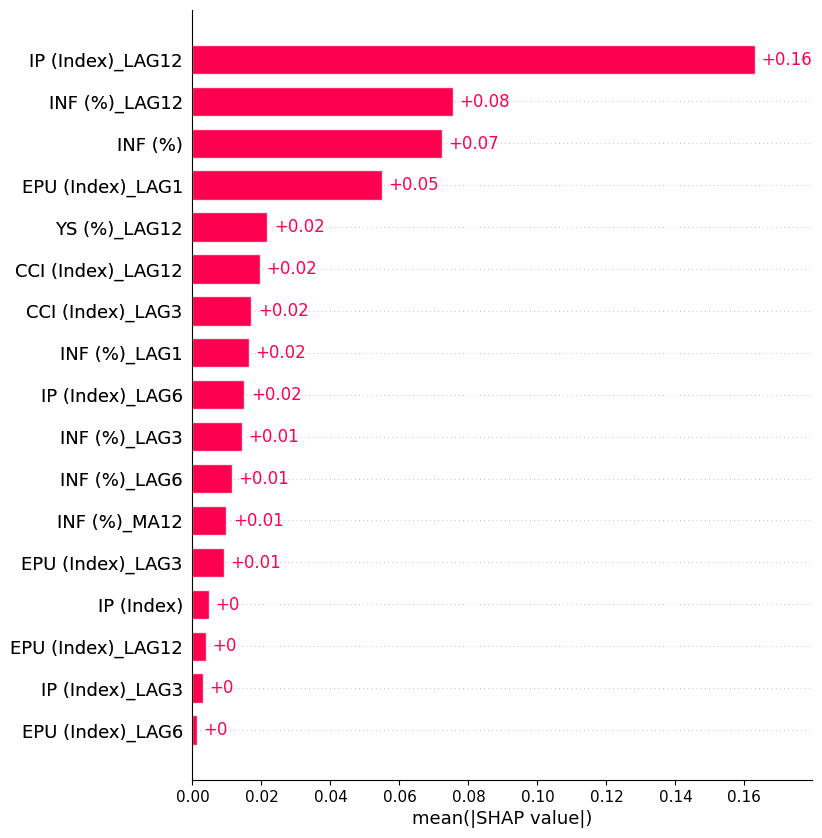

In [510]:
shap.plots.bar(
    shap.Explanation(
        values=shap_array,
        base_values=shap_values.base_values[:, 1],
        data=X_train.values,
        feature_names=X_train.columns
    ),
    max_display=20,
    show=True
)

### Store the results on a dataframe for display

In [511]:
all_results.append({
    "Country": country,
    "Target": target,
    "Threshold": best_thresh,
    "AUC": auc,
    "F1": f1,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "Train Size": len(y_train),
    "Validation Size": len(y_val),
    "Test Size": len(y_test)
})
results_df = pd.DataFrame(all_results)


In [512]:
results_df.to_csv(os.path.join(metrics_dir, f"RFC_evaluation_metrics_{target}_email_per_country.csv"), index=False)
results_df

,Country,Target,Threshold,AUC,F1,Precision,Recall,Accuracy,Train Size,Validation Size,Test Size
0,USA,RECESS,0.50,0.420635,0.000000,0.000000,0.000000,0.769231,180,108,65
1,CAN,RECESS,0.27,0.781513,0.354430,0.215385,1.000000,0.215385,180,108,65
2,MEX,RECESS,0.11,0.172181,0.222222,0.152174,0.411765,0.246154,180,108,65
3,GER,RECESS,0.18,0.354779,0.414634,0.261538,1.000000,0.261538,180,108,65
4,CHI,RECESS,0.31,0.638095,0.700000,0.538462,1.000000,0.538462,180,108,65
5,JAP,RECESS,0.16,0.887868,0.472222,0.309091,1.000000,0.415385,180,108,65
6,USA,RECESS_OVER,0.50,0.309426,0.000000,0.000000,0.000000,0.892308,180,108,65
7,CAN,RECESS_OVER,0.17,0.588816,0.222222,0.125000,1.000000,0.138462,180,108,65
8,MEX,RECESS_OVER,0.50,0.442308,0.000000,0.000000,0.000000,0.800000,180,108,65
9,GER,RECESS_OVER,0.10,0.182377,0.000000,0.000000,0.000000,0.353846,180,108,65
